# 03 - Exploratory Data Analysis
### Student Course Completion Prediction Dataset

Univariate, bivariate, and multivariate analysis on the cleaned dataset, built to answer the
business questions from the project's problem statement: what separates completers from non
completers, which segments underperform, and whether `Progress_Percentage` actually gates
completion the way it's assumed to.

Every chart below has a one to two line insight written underneath it in markdown, tied back to a
business question, not just a description of the chart.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"
ORANGE = "#ea580c"
DARK = "#1f2937"
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

df = pd.read_csv("../data/processed/clean_student_data.csv", parse_dates=["Enrollment_Date"])
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded 100000 rows, 48 columns


,Student_ID,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,Course_Name,Category,Course_Level,Course_Duration_Days,Instructor_Rating,Login_Frequency,Average_Session_Duration_Min,Video_Completion_Rate,Discussion_Participation,Time_Spent_Hours,Days_Since_Last_Login,Notifications_Checked,Peer_Interaction_Score,Assignments_Submitted,Assignments_Missed,Quiz_Attempts,Quiz_Score_Avg,Project_Grade,Progress_Percentage,Rewatch_Count,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,Payment_Amount,App_Usage_Percentage,Reminder_Emails_Clicked,Support_Tickets_Raised,Satisfaction_Rating,Completed,enrollment_year,enrollment_month,is_scholarship_partial_pay,completed_flag,performance_score,assignment_completion_rate,engagement_score,engagement_tier,age_band
0,STU100000,Male,19,Diploma,Student,Indore,Laptop,Medium,C102,Data Analysis with Python,Programming,Intermediate,60,4.7,3,30,55.0,2,0.5,1,6,4.3,8,1,5,80.9,71.2,70.8,0,2024-06-01,Scholarship,No,No,1740,49,3,4,3.5,Completed,2024,2024-06,1,1,76.05,0.888889,30.421760,Low,Under 20
1,STU100001,Female,17,Bachelor,Student,Delhi,Laptop,Low,C106,Machine Learning A-Z,Programming,Advanced,90,4.6,4,37,84.1,2,0.9,3,5,7.8,4,6,3,78.4,42.5,55.6,2,2025-04-27,Credit Card,Yes,No,6147,86,0,0,4.5,Not Completed,2025,2025-04,0,0,60.45,0.400000,49.402797,High,Under 20
2,STU100002,Female,34,Master,Student,Chennai,Mobile,Medium,C101,Python Basics,Programming,Beginner,45,4.6,5,9,75.6,3,0.5,19,5,6.7,8,2,3,100.0,87.9,78.8,2,2024-01-20,NetBanking,Yes,No,4280,85,1,0,5.0,Completed,2024,2024-01,0,1,93.95,0.800000,48.181858,High,30-34
3,STU100003,Female,29,Diploma,Employed,Surat,Mobile,High,C105,UI/UX Design Fundamentals,Design,Beginner,40,4.4,2,27,63.3,1,7.4,19,9,6.4,0,10,4,59.1,51.4,24.7,4,2025-05-13,UPI,Yes,No,3812,42,2,3,3.8,Completed,2025,2025-05,0,1,55.25,0.000000,36.064115,Low,25-29
4,STU100004,Female,19,Master,Self-Employed,Lucknow,Laptop,Medium,C106,Machine Learning A-Z,Programming,Advanced,90,4.6,2,36,86.4,1,0.5,4,7,7.5,5,5,8,84.8,93.0,64.9,4,2024-12-19,Debit Card,Yes,Yes,5486,91,3,0,4.0,Completed,2024,2024-12,0,1,88.90,0.500000,47.526958,High,Under 20


## Summary statistics

Mean, median, standard deviation, and percentiles across every numeric field.

In [2]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,25.709590,5.615292,17.000000,21.000000,25.000000,30.000000,52.000000
Course_Duration_Days,100000.0,51.817300,20.324801,25.000000,30.000000,45.000000,60.000000,90.000000
Instructor_Rating,100000.0,4.444478,0.202631,4.100000,4.300000,4.500000,4.600000,4.700000
Login_Frequency,100000.0,4.785380,1.848289,0.000000,3.000000,5.000000,6.000000,15.000000
Average_Session_Duration_Min,100000.0,33.878180,10.341964,5.000000,27.000000,34.000000,41.000000,81.000000
Video_Completion_Rate,100000.0,62.174580,19.558126,5.000000,48.500000,64.000000,77.500000,99.900000
Discussion_Participation,100000.0,2.329290,1.591365,0.000000,1.000000,2.000000,3.000000,12.000000
Time_Spent_Hours,100000.0,3.873632,3.781185,0.500000,0.500000,2.700000,6.200000,25.600000
Days_Since_Last_Login,100000.0,6.188860,6.982047,0.000000,1.000000,4.000000,9.000000,99.000000
Notifications_Checked,100000.0,5.232110,2.401486,0.000000,4.000000,5.000000,7.000000,18.000000


---
# Part 1: Univariate Analysis
---

### Chart 1 - Target distribution (Completed)

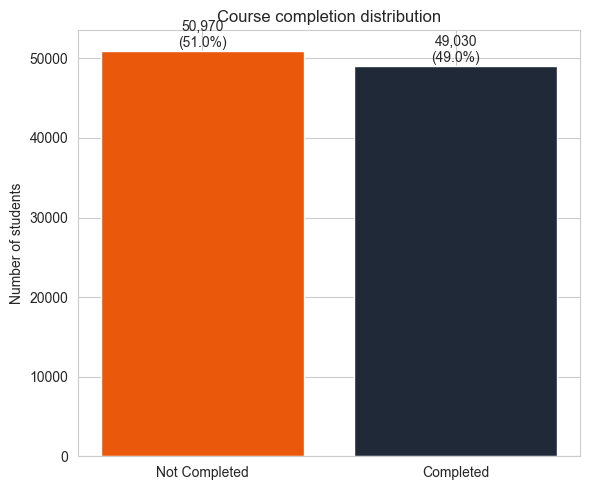

In [3]:
plt.figure(figsize=(6, 5))
counts = df["Completed"].value_counts()
plt.bar(counts.index, counts.values, color=[ORANGE, DARK])
for i, v in enumerate(counts.values):
    plt.text(i, v + 500, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=10)
plt.title("Course completion distribution")
plt.ylabel("Number of students")
plt.tight_layout()
plt.show()

**Insight:** the dataset is close to perfectly balanced, 49% completed versus 51% not completed.
That's good news for the analysis, there's no need to worry about a skewed target hiding weak
signal in the minority class, and any completion rate gap found between segments later is a real
gap, not an artifact of class imbalance.

### Chart 2 - Age distribution

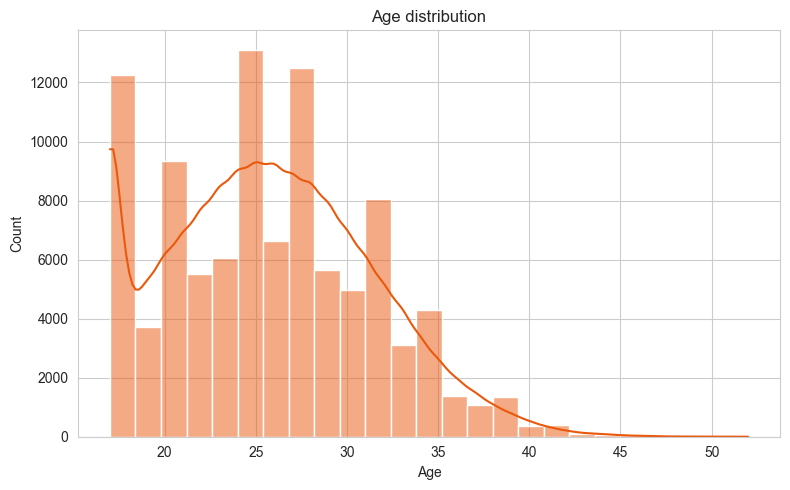

In [4]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], bins=25, kde=True, color=ORANGE)
plt.title("Age distribution")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

**Insight:** the learner base skews young, concentrated in the 20s, consistent with an online
upskilling platform aimed at students and early-career professionals rather than a general adult
education audience.

### Chart 3 - Category and Course_Level counts

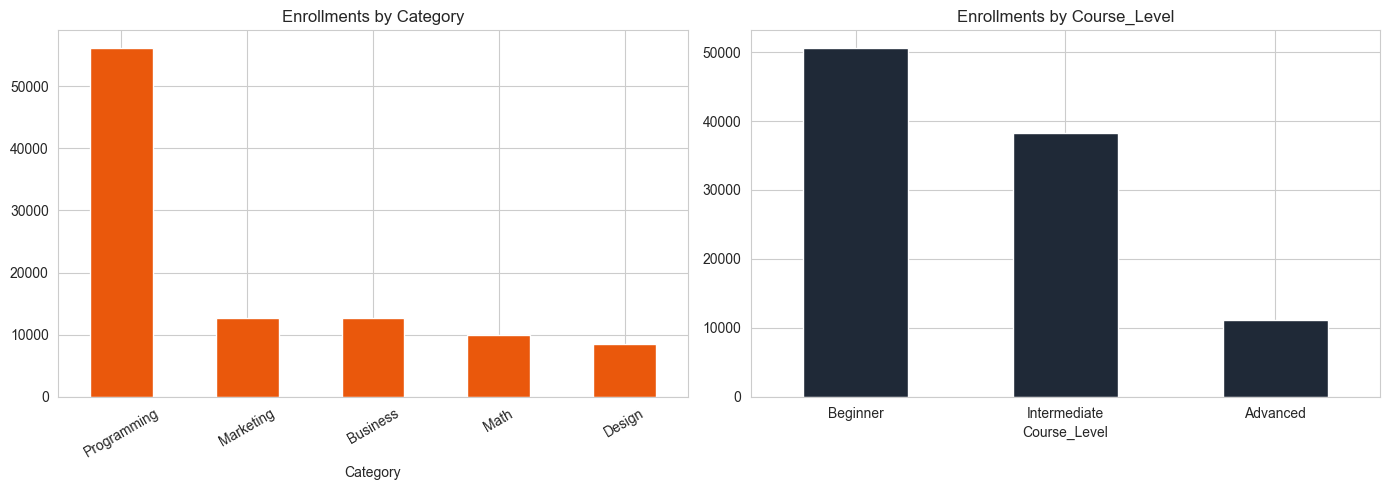

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["Category"].value_counts().plot(kind="bar", ax=axes[0], color=ORANGE)
axes[0].set_title("Enrollments by Category")
axes[0].tick_params(axis="x", rotation=30)

df["Course_Level"].value_counts().plot(kind="bar", ax=axes[1], color=DARK)
axes[1].set_title("Enrollments by Course_Level")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

**Insight:** Programming dominates enrollment volume, and Beginner-level courses attract the
most students by a wide margin. Any completion-rate finding for smaller categories like Design or
Math needs to be read with that volume difference in mind.

### Chart 4 - Engagement field distributions

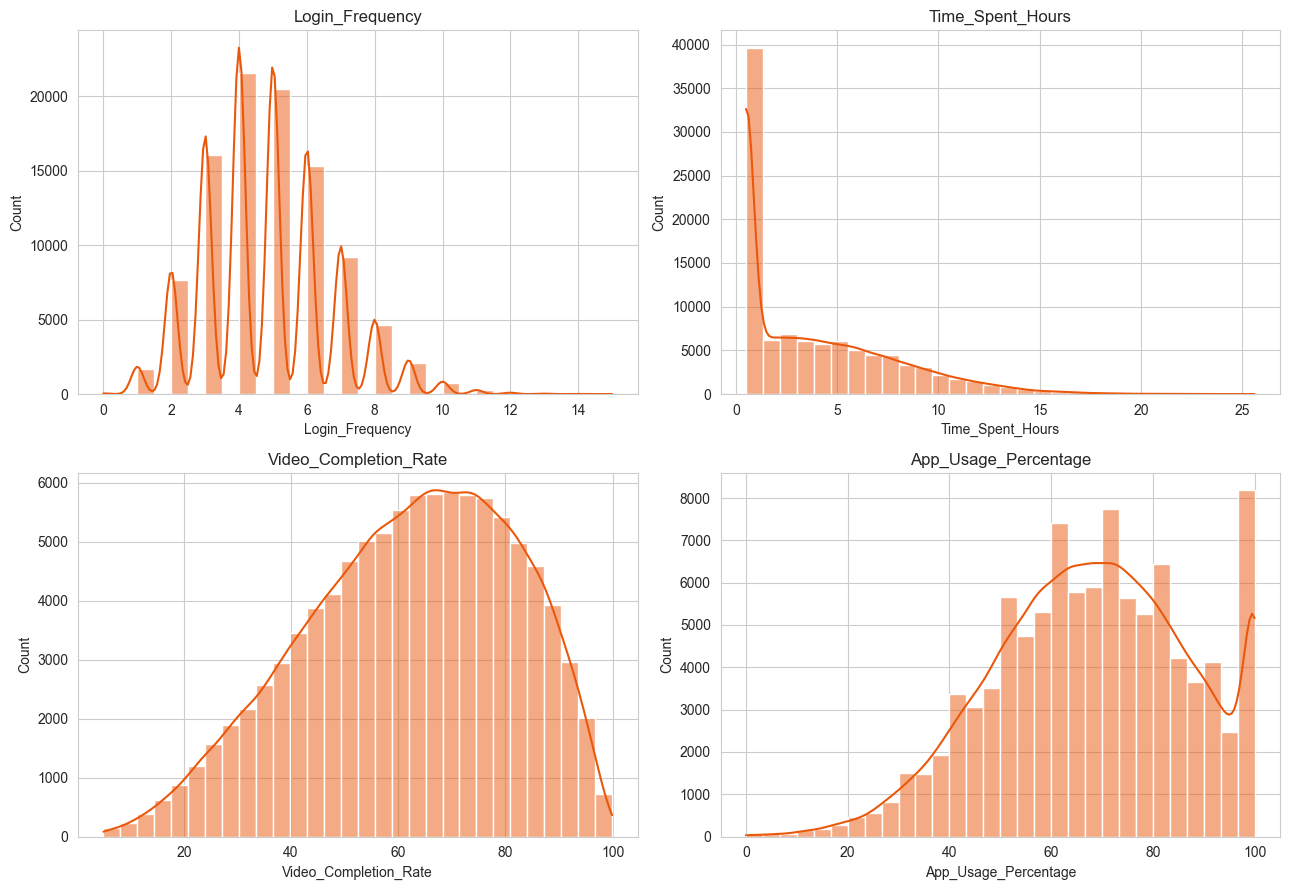

In [6]:
engagement_fields = ["Login_Frequency", "Time_Spent_Hours", "Video_Completion_Rate", "App_Usage_Percentage"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for i, col in enumerate(engagement_fields):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color=ORANGE)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

**Insight:** `Video_Completion_Rate` and `App_Usage_Percentage` are fairly spread across their
full range rather than clustering near 100%, meaning a large share of the student base never gets
close to full engagement, this is the raw material for the risk segmentation later in the
dashboard.

### Chart 5 - Performance field distributions

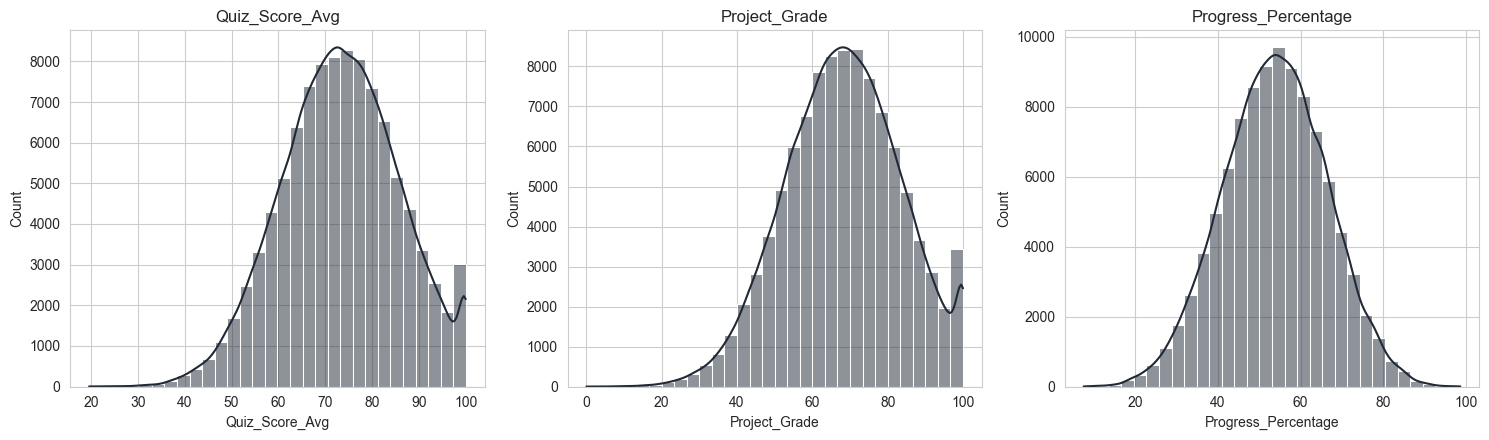

In [7]:
perf_fields = ["Quiz_Score_Avg", "Project_Grade", "Progress_Percentage"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for i, col in enumerate(perf_fields):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color=DARK)
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

**Insight:** `Progress_Percentage` is the widest-spread of the three, while `Quiz_Score_Avg` and
`Project_Grade` sit in a tighter, higher band. That gap in spread is an early hint that progress
tracking and actual performance are not moving together, which is exactly the pattern flagged
during data quality assessment.

### Chart 6 - Payment mode and Employment status counts

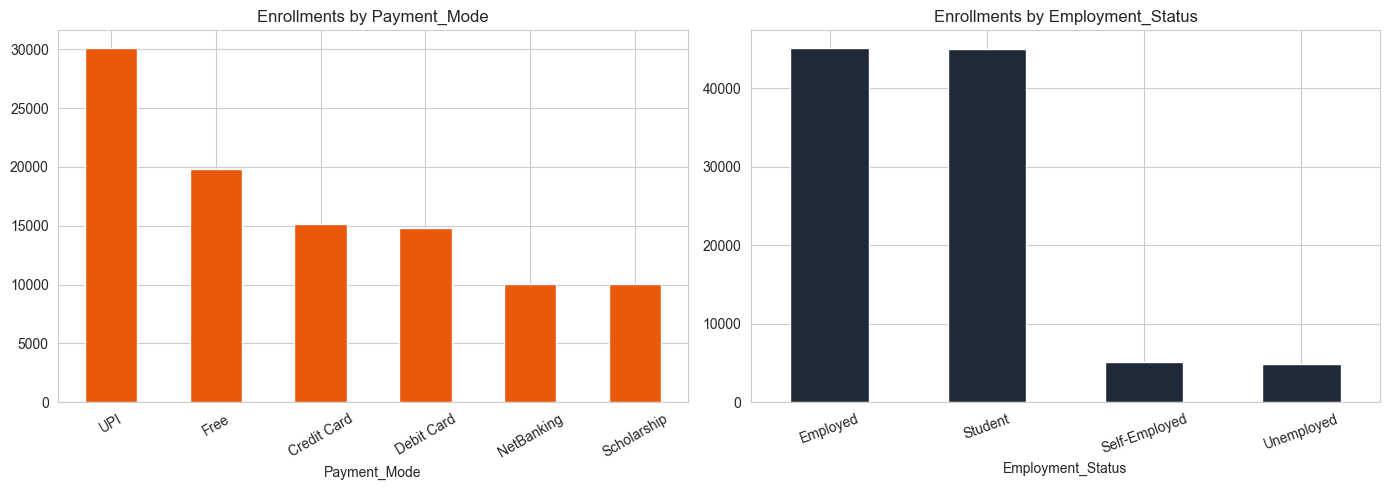

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["Payment_Mode"].value_counts().plot(kind="bar", ax=axes[0], color=ORANGE)
axes[0].set_title("Enrollments by Payment_Mode")
axes[0].tick_params(axis="x", rotation=30)

df["Employment_Status"].value_counts().plot(kind="bar", ax=axes[1], color=DARK)
axes[1].set_title("Enrollments by Employment_Status")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

**Insight:** UPI and Free enrollments make up the bulk of the base, and Employed and Student
status are roughly tied as the two largest employment groups, Unemployed and Self-Employed are
comparatively small segments.

---
# Part 2: Bivariate Analysis
---

### Chart 7 - Completion rate by Category

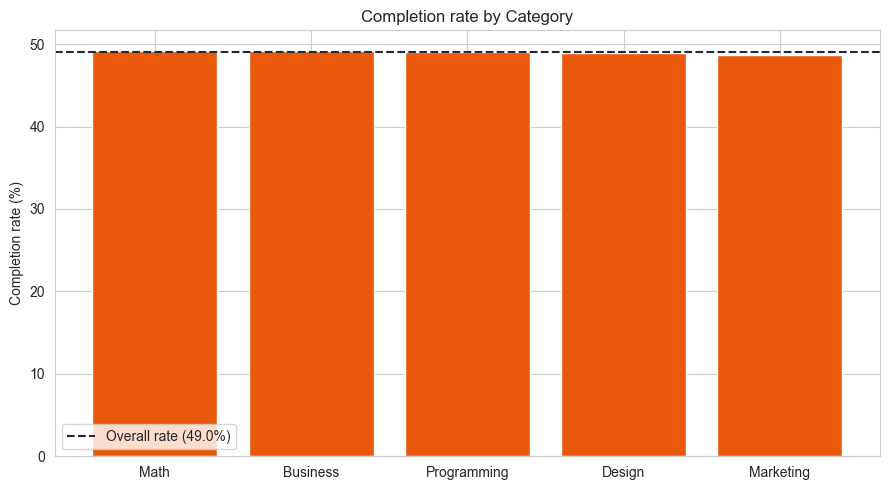

Category
Math           49.197007
Business       49.133085
Programming    49.072492
Design         48.927646
Marketing      48.675706
Name: completed_flag, dtype: float64

In [9]:
comp_by_cat = df.groupby("Category")["completed_flag"].mean().sort_values(ascending=False) * 100
overall_rate = df["completed_flag"].mean() * 100

plt.figure(figsize=(9, 5))
bars = plt.bar(comp_by_cat.index, comp_by_cat.values, color=ORANGE)
plt.axhline(overall_rate, color=DARK, linestyle="--", label=f"Overall rate ({overall_rate:.1f}%)")
plt.title("Completion rate by Category")
plt.ylabel("Completion rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

comp_by_cat

**Insight:** completion rate by category is the first place to look for structural risk. Any
category sitting noticeably below the dashed overall-average line is underperforming and worth a
closer look, whether that's course design, difficulty pacing, or the kind of student it tends to
attract.

### Chart 8 - Completion rate by Course_Level

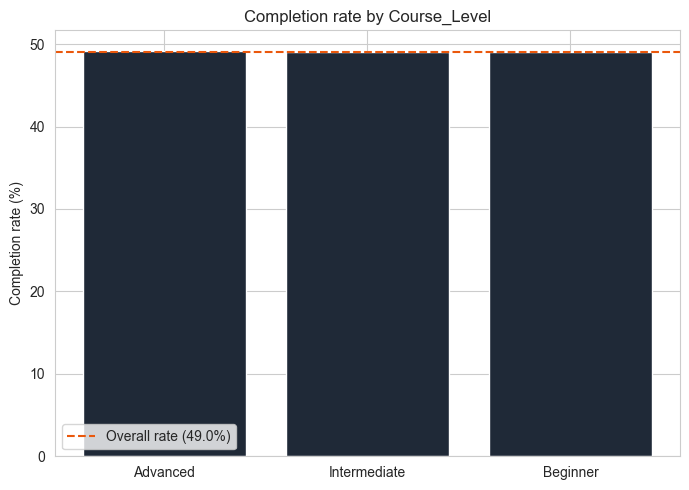

Course_Level
Advanced        49.196285
Intermediate    49.033829
Beginner        48.990318
Name: completed_flag, dtype: float64

In [10]:
comp_by_level = df.groupby("Course_Level")["completed_flag"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(7, 5))
plt.bar(comp_by_level.index, comp_by_level.values, color=DARK)
plt.axhline(overall_rate, color=ORANGE, linestyle="--", label=f"Overall rate ({overall_rate:.1f}%)")
plt.title("Completion rate by Course_Level")
plt.ylabel("Completion rate (%)")
plt.legend()
plt.tight_layout()
plt.show()

comp_by_level

**Insight:** if Advanced courses show a lower completion rate than Beginner courses, that
supports a fairly intuitive story, harder material loses more people. If the levels come out close
to each other instead, that's actually the more interesting finding, it means difficulty isn't the
main driver of drop-off and the real cause sits elsewhere (engagement, pacing, or support).

### Chart 9 - Completion rate by Employment_Status and Payment_Mode

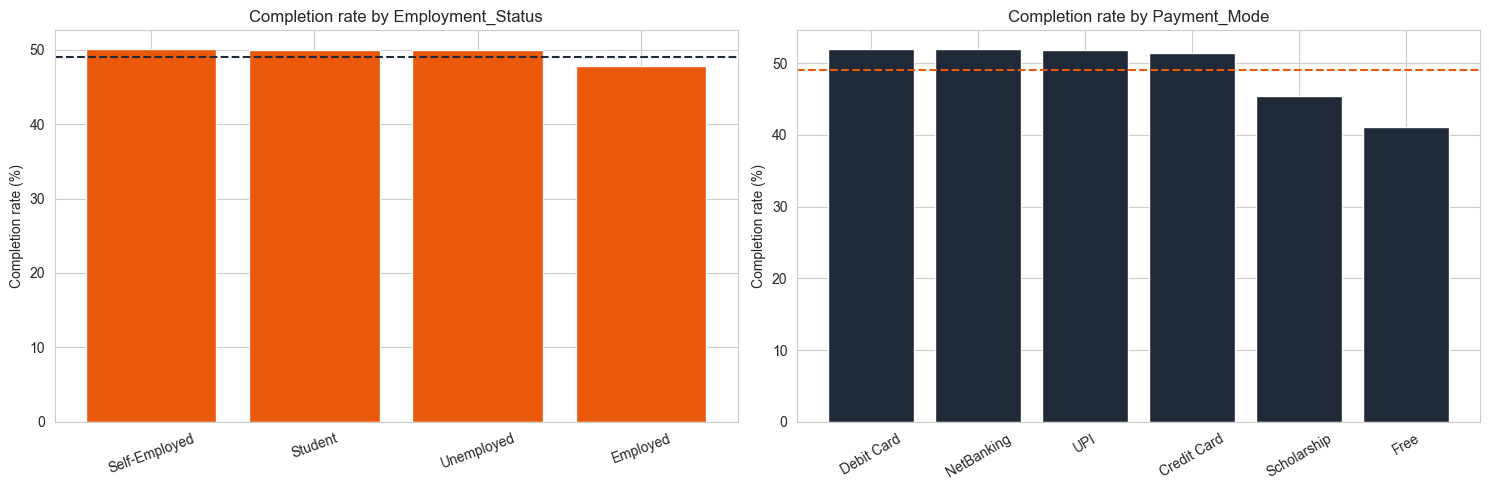

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

comp_by_emp = df.groupby("Employment_Status")["completed_flag"].mean().sort_values(ascending=False) * 100
axes[0].bar(comp_by_emp.index, comp_by_emp.values, color=ORANGE)
axes[0].axhline(overall_rate, color=DARK, linestyle="--")
axes[0].set_title("Completion rate by Employment_Status")
axes[0].set_ylabel("Completion rate (%)")
axes[0].tick_params(axis="x", rotation=20)

comp_by_pay = df.groupby("Payment_Mode")["completed_flag"].mean().sort_values(ascending=False) * 100
axes[1].bar(comp_by_pay.index, comp_by_pay.values, color=DARK)
axes[1].axhline(overall_rate, color=ORANGE, linestyle="--")
axes[1].set_title("Completion rate by Payment_Mode")
axes[1].set_ylabel("Completion rate (%)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Insight:** this checks whether financial commitment (a paid mode versus Free or Scholarship)
or life circumstance (Employed versus Student versus Unemployed) has any real pull on whether
someone finishes. If Free enrollments complete at a noticeably lower rate than paid ones, that
supports a classic "sunk cost" story, paying for something makes people more likely to finish it.

### Chart 10 - Engagement and performance fields, completers vs non completers

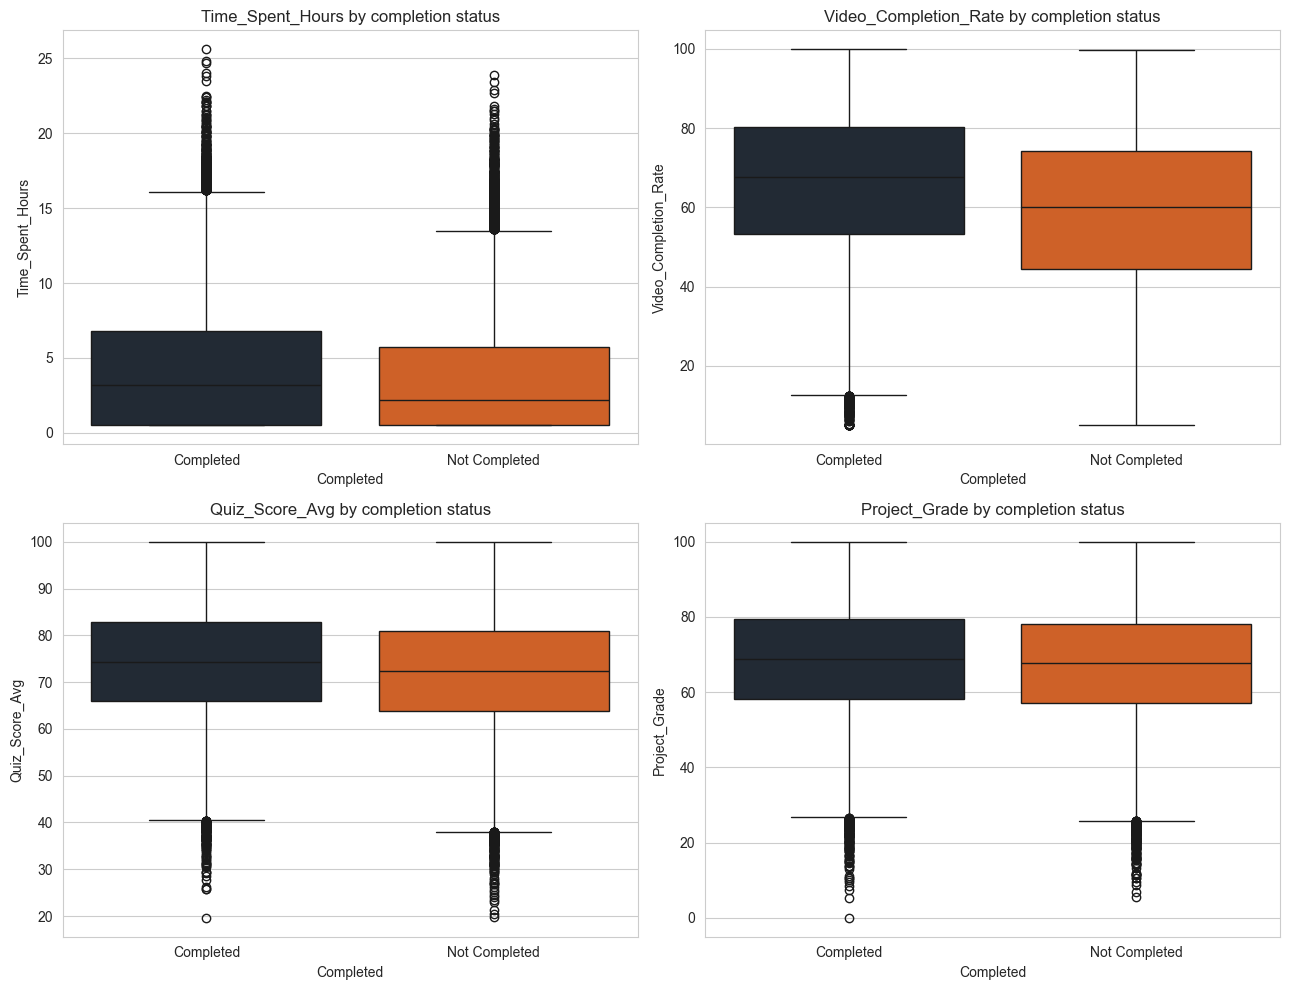

In [23]:
compare_fields = ["Time_Spent_Hours", "Video_Completion_Rate", "Quiz_Score_Avg", "Project_Grade"]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()
for i, col in enumerate(compare_fields):
    sns.boxplot(data=df, x="Completed", y=col, ax=axes[i], palette=[DARK, ORANGE], hue="Completed", legend=False)
    axes[i].set_title(f"{col} by completion status")
plt.tight_layout()
plt.show()

In [13]:
print("Median values, completers vs non completers:\n")
print(df.groupby("Completed")[compare_fields].median().T)

Median values, completers vs non completers:

Completed              Completed  Not Completed
Time_Spent_Hours             3.2            2.2
Video_Completion_Rate       67.7           60.0
Quiz_Score_Avg              74.4           72.4
Project_Grade               68.9           67.7


**Insight:** this is the clearest evidence in the whole notebook for what actually separates the
two groups. Whichever field shows the widest gap between the two boxes is the strongest single
behavioral signal, and the median table above turns that gap into an exact number worth quoting in
the business insights report.

### Chart 11 - Correlation heatmap

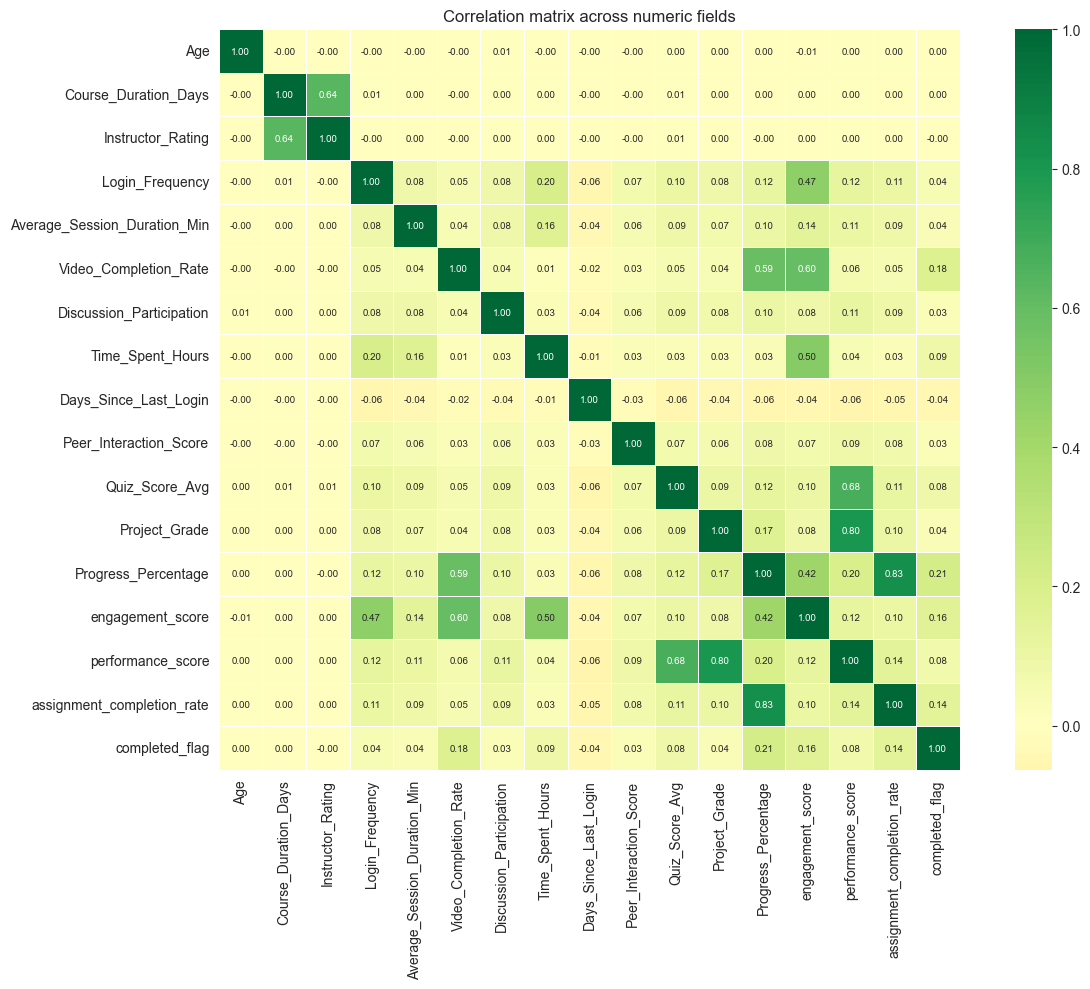

In [14]:
corr_fields = ["Age", "Course_Duration_Days", "Instructor_Rating", "Login_Frequency",
               "Average_Session_Duration_Min", "Video_Completion_Rate", "Discussion_Participation",
               "Time_Spent_Hours", "Days_Since_Last_Login", "Peer_Interaction_Score",
               "Quiz_Score_Avg", "Project_Grade", "Progress_Percentage", "engagement_score",
               "performance_score", "assignment_completion_rate", "completed_flag"]

corr_matrix = df[corr_fields].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            square=True, linewidths=0.5, annot_kws={"size": 7})
plt.title("Correlation matrix across numeric fields")
plt.tight_layout()
plt.show()

In [15]:
target_corr = corr_matrix["completed_flag"].drop("completed_flag").sort_values(ascending=False)
print("Correlation with completed_flag, strongest first:\n")
target_corr

Correlation with completed_flag, strongest first:



Progress_Percentage             0.214026
Video_Completion_Rate           0.175222
engagement_score                0.163199
assignment_completion_rate      0.144122
Time_Spent_Hours                0.090079
Quiz_Score_Avg                  0.080957
performance_score               0.076419
Login_Frequency                 0.043300
Average_Session_Duration_Min    0.037160
Project_Grade                   0.036940
Discussion_Participation        0.027553
Peer_Interaction_Score          0.025165
Course_Duration_Days            0.001341
Age                             0.000299
Instructor_Rating              -0.000233
Days_Since_Last_Login          -0.044754
Name: completed_flag, dtype: float64

**Insight:** the printed ranking above is the single most useful table in this notebook. The top
few fields by correlation are the strongest linear predictors of completion, and if
`Days_Since_Last_Login` shows a strong negative correlation, that confirms recency of activity is
one of the most reliable early-warning signals available, more useful than progress tracking.

### Chart 12 - Progress_Percentage vs Completed, the flagged mismatch

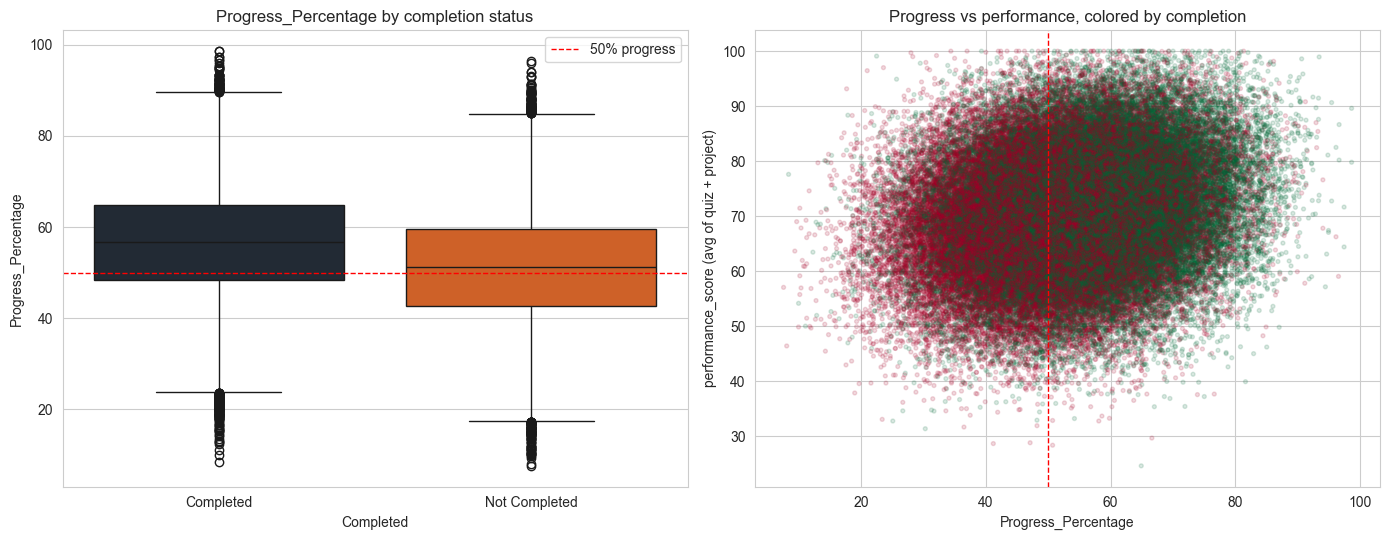

29.3% of completed students had under 50% logged progress


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.boxplot(data=df, x="Completed", y="Progress_Percentage", ax=axes[0], palette=[DARK, ORANGE], hue="Completed", legend=False)
axes[0].axhline(50, color="red", linestyle="--", linewidth=1, label="50% progress")
axes[0].set_title("Progress_Percentage by completion status")
axes[0].legend()

low_progress_completed = df[(df["Completed"] == "Completed") & (df["Progress_Percentage"] < 50)]
pct_of_completed = len(low_progress_completed) / (df["Completed"] == "Completed").sum() * 100

axes[1].scatter(df["Progress_Percentage"], df["performance_score"],
                    c=df["completed_flag"], cmap="RdYlGn", alpha=0.15, s=8)
axes[1].axvline(50, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Progress_Percentage")
axes[1].set_ylabel("performance_score (avg of quiz + project)")
axes[1].set_title("Progress vs performance, colored by completion")

plt.tight_layout()
plt.show()

print(f"{pct_of_completed:.1f}% of completed students had under 50% logged progress")

**Insight:** this is the direct test of the anomaly flagged during data quality assessment. If a
sizeable share of completed students still show low `Progress_Percentage`, and the scatter plot
shows those same students clustering at high `performance_score`, that confirms completion is
being gated by quiz and project performance rather than by how much of the course content was
progressed through. That is a genuinely actionable finding: `Progress_Percentage` alone is not a
reliable early-warning metric, performance_score is the stronger signal to track instead.

---
# Part 3: Multivariate Analysis
---

### Chart 13 - Category x engagement_tier, completion rate

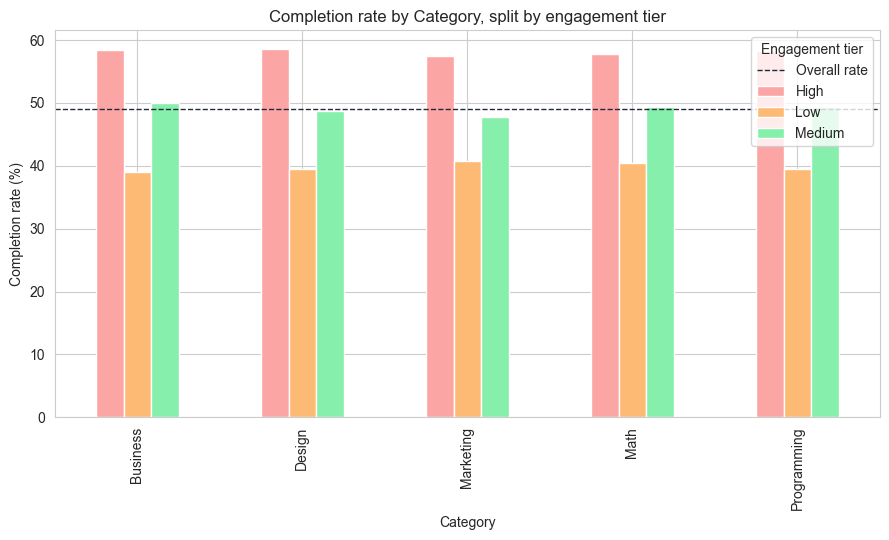

engagement_tier,High,Low,Medium
Category,,,
Business,58.4,39.0,50.0
Design,58.6,39.5,48.8
Marketing,57.4,40.8,47.8
Math,57.8,40.5,49.4
Programming,58.3,39.5,49.4


In [17]:
pivot = df.pivot_table(values="completed_flag", index="Category", columns="engagement_tier",
                        aggfunc="mean") * 100

plt.figure(figsize=(9, 5.5))
pivot.plot(kind="bar", ax=plt.gca(), color=["#fca5a5", "#fdba74", "#86efac"])
plt.axhline(overall_rate, color=DARK, linestyle="--", linewidth=1, label="Overall rate")
plt.title("Completion rate by Category, split by engagement tier")
plt.ylabel("Completion rate (%)")
plt.legend(title="Engagement tier")
plt.tight_layout()
plt.show()

pivot.round(1)

**Insight:** this shows whether engagement tier closes the gap between categories or whether the
category effect holds regardless of engagement level. If High-engagement students complete at a
similarly strong rate across every category, that means engagement is the dominant lever, and
course category matters much less once a student is actually engaged, good news for where to
target intervention effort.

### Chart 14 - Scatter matrix of key numeric predictors, colored by completion

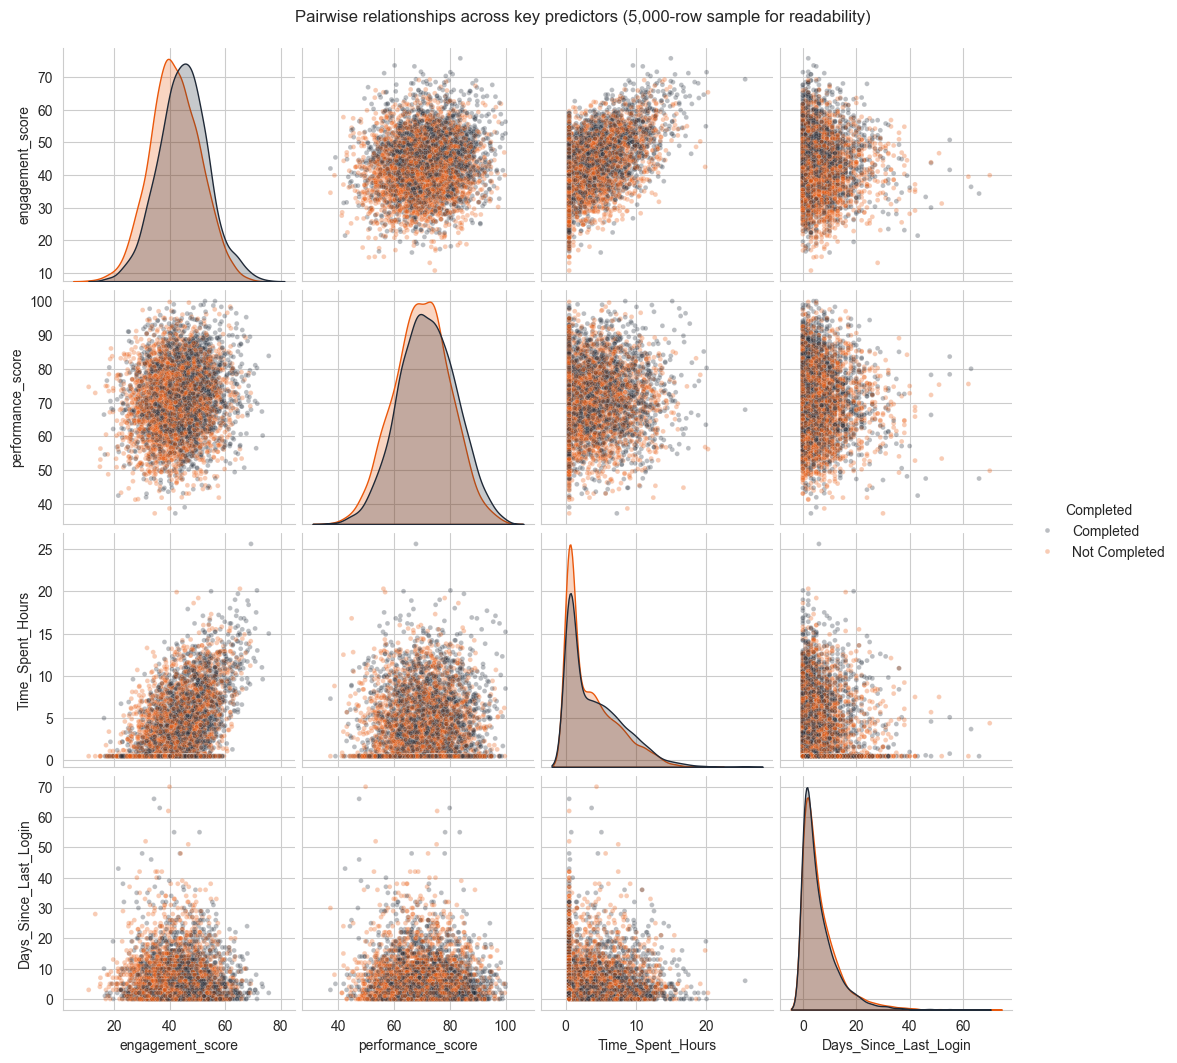

In [18]:
scatter_fields = ["engagement_score", "performance_score", "Time_Spent_Hours", "Days_Since_Last_Login"]
sample_for_plot = df.sample(n=min(5000, len(df)), random_state=42)

fig = sns.pairplot(sample_for_plot, vars=scatter_fields, hue="Completed",
                    palette=[DARK, ORANGE], plot_kws={"alpha": 0.3, "s": 12}, height=2.6)
fig.fig.suptitle("Pairwise relationships across key predictors (5,000-row sample for readability)", y=1.02)
plt.show()

**Insight:** `engagement_score` and `performance_score` are the two fields most likely to show
clean visual separation between the orange and dark point clouds, since these are the two
engineered features built specifically to summarize the raw behavioral signal. If those two panels
show cleaner separation than the raw fields (like `Time_Spent_Hours` alone), it validates that the
feature engineering in notebook 02 was worth doing.

### Chart 15 - Feature importance (Random Forest)

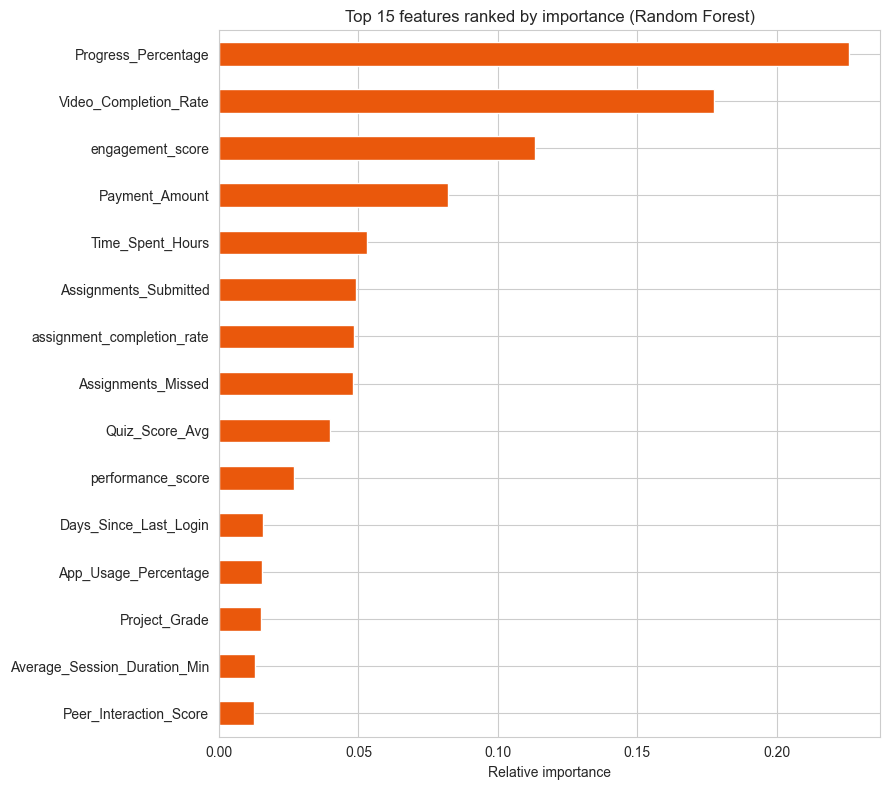

Model accuracy on training data (indicative only, not a held-out test): 0.623


Progress_Percentage             0.225790
Video_Completion_Rate           0.177639
engagement_score                0.113476
Payment_Amount                  0.082210
Time_Spent_Hours                0.053197
Assignments_Submitted           0.049095
assignment_completion_rate      0.048260
Assignments_Missed              0.048198
Quiz_Score_Avg                  0.039610
performance_score               0.026995
Days_Since_Last_Login           0.015611
App_Usage_Percentage            0.015509
Project_Grade                   0.014986
Average_Session_Duration_Min    0.012883
Peer_Interaction_Score          0.012642
dtype: float64

In [19]:
model_fields = ["Age", "Course_Duration_Days", "Instructor_Rating", "Login_Frequency",
                "Average_Session_Duration_Min", "Video_Completion_Rate", "Discussion_Participation",
                "Time_Spent_Hours", "Days_Since_Last_Login", "Notifications_Checked",
                "Peer_Interaction_Score", "Assignments_Submitted", "Assignments_Missed",
                "Quiz_Attempts", "Quiz_Score_Avg", "Project_Grade", "Progress_Percentage",
                "Rewatch_Count", "Payment_Amount", "App_Usage_Percentage",
                "Reminder_Emails_Clicked", "Support_Tickets_Raised", "Satisfaction_Rating",
                "engagement_score", "performance_score", "assignment_completion_rate"]

X = df[model_fields].fillna(0)
y = df["completed_flag"]

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=model_fields).sort_values(ascending=False)

plt.figure(figsize=(9, 8))
importance.head(15).sort_values().plot(kind="barh", color=ORANGE)
plt.title("Top 15 features ranked by importance (Random Forest)")
plt.xlabel("Relative importance")
plt.tight_layout()
plt.show()

print(f"Model accuracy on training data (indicative only, not a held-out test): {rf.score(X, y):.3f}")
importance.head(15)

**Insight:** this ranking exists purely to answer "what actually drives completion", not to ship
a production model, so training accuracy is reported just as a sanity check rather than a
performance claim. Whatever tops this list, cross-referenced against the correlation ranking from
Chart 11, is the evidence-backed shortlist for the business insights report. Anything that shows up
strong in both the correlation table and this importance ranking is about as solid a finding as
this dataset can support.

### Chart 16 - Enrollment and completion trend over time

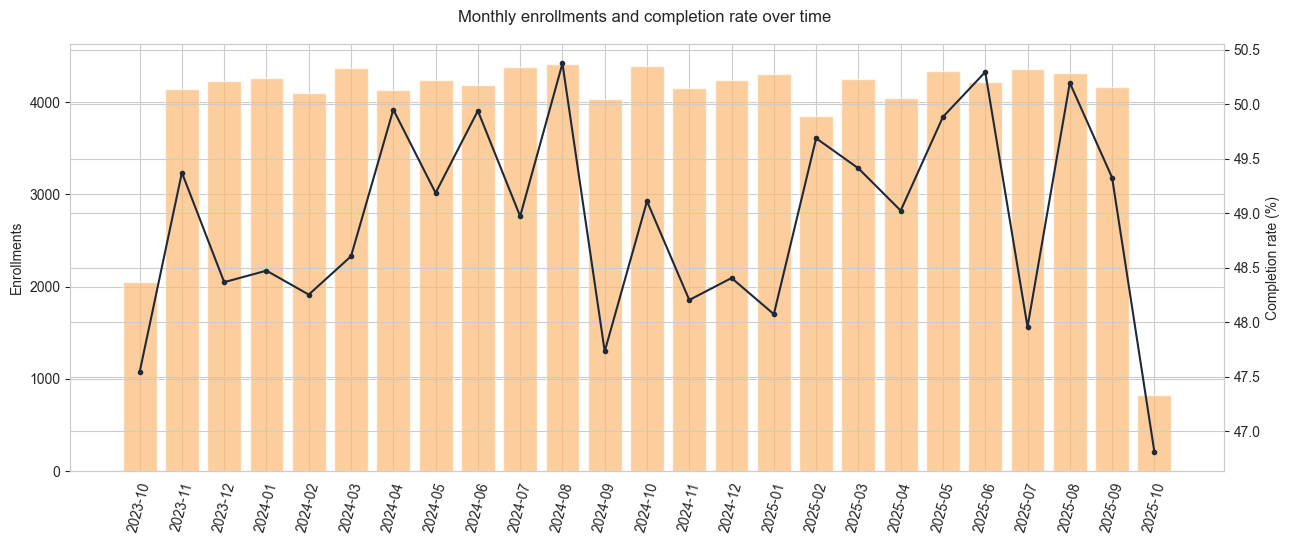

In [20]:
monthly = df.groupby("enrollment_month").agg(
    enrollments=("Student_ID", "count"),
    completion_rate=("completed_flag", "mean")
).reset_index()
monthly["completion_rate"] *= 100
monthly = monthly.sort_values("enrollment_month")

fig, ax1 = plt.subplots(figsize=(13, 5.5))
ax1.bar(monthly["enrollment_month"], monthly["enrollments"], color="#fdba74", alpha=0.7, label="Enrollments")
ax1.set_ylabel("Enrollments")
ax1.tick_params(axis="x", rotation=75)

ax2 = ax1.twinx()
ax2.plot(monthly["enrollment_month"], monthly["completion_rate"], color=DARK, marker="o", markersize=3, label="Completion rate")
ax2.set_ylabel("Completion rate (%)")

fig.suptitle("Monthly enrollments and completion rate over time")
fig.tight_layout()
plt.show()

**Insight:** this shows whether completion rate has been drifting over time, improving,
worsening, or holding steady as enrollment volume changed. A steady rate despite growing volume is
a good operational sign, a declining rate as volume grows would suggest the platform's support or
content quality hasn't kept pace with scale.

---
## EDA Summary

Charts produced: 6 univariate, 6 bivariate, 4 multivariate, 16 total, covering demographic,
engagement, performance, and payment dimensions plus a dedicated investigation into the
Progress_Percentage anomaly flagged during data quality assessment.

The next step (Section 6 of the project, written in the final report) pulls the concrete numbers
out of the outputs above, into the business insights and recommendations.